Cleaned data shape: (1063610, 7)
Temperature column used: value
           date      value    model    scenario variable  year  month
1460 2004-01-01  13.847445  BNU-ESM  historical    tmean  2004      1
1461 2004-01-02  14.117373  BNU-ESM  historical    tmean  2004      1
1462 2004-01-03  14.266186  BNU-ESM  historical    tmean  2004      1
1463 2004-01-04  14.406878  BNU-ESM  historical    tmean  2004      1
1464 2004-01-05  14.967586  BNU-ESM  historical    tmean  2004      1
Monthly data:
    organism    scenario      model  year  month  base_temp  \
0  Cockroach  historical  ACCESS1-0  2004      1       15.9   
1  Cockroach  historical  ACCESS1-0  2004      2       15.9   
2  Cockroach  historical  ACCESS1-0  2004      3       15.9   
3  Cockroach  historical  ACCESS1-0  2004      4       15.9   
4  Cockroach  historical  ACCESS1-0  2004      5       15.9   

   dd_per_generation  monthly_dd  monthly_generation_equivalent  
0                650   23.728079                       0.

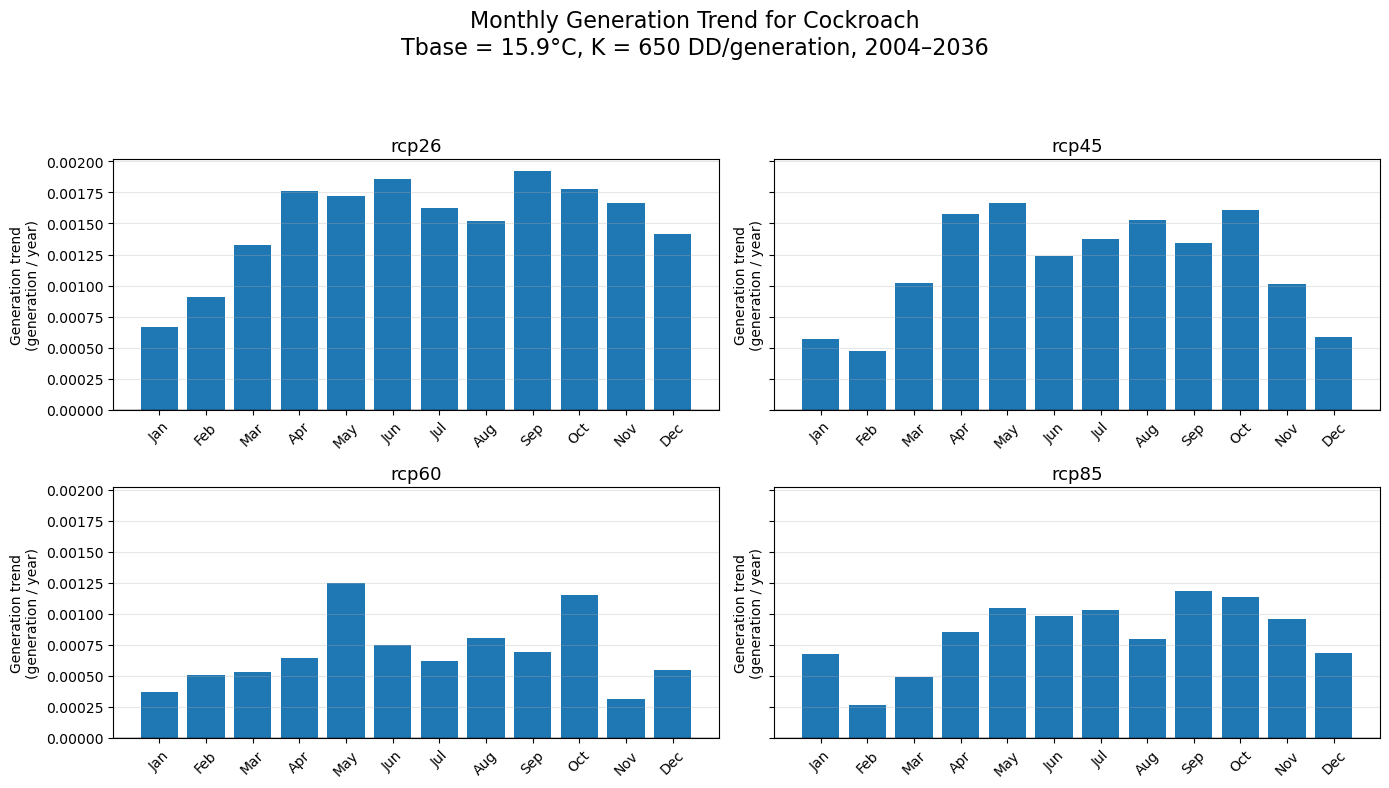

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_generation_slope_Cockroach_2004_2036.png


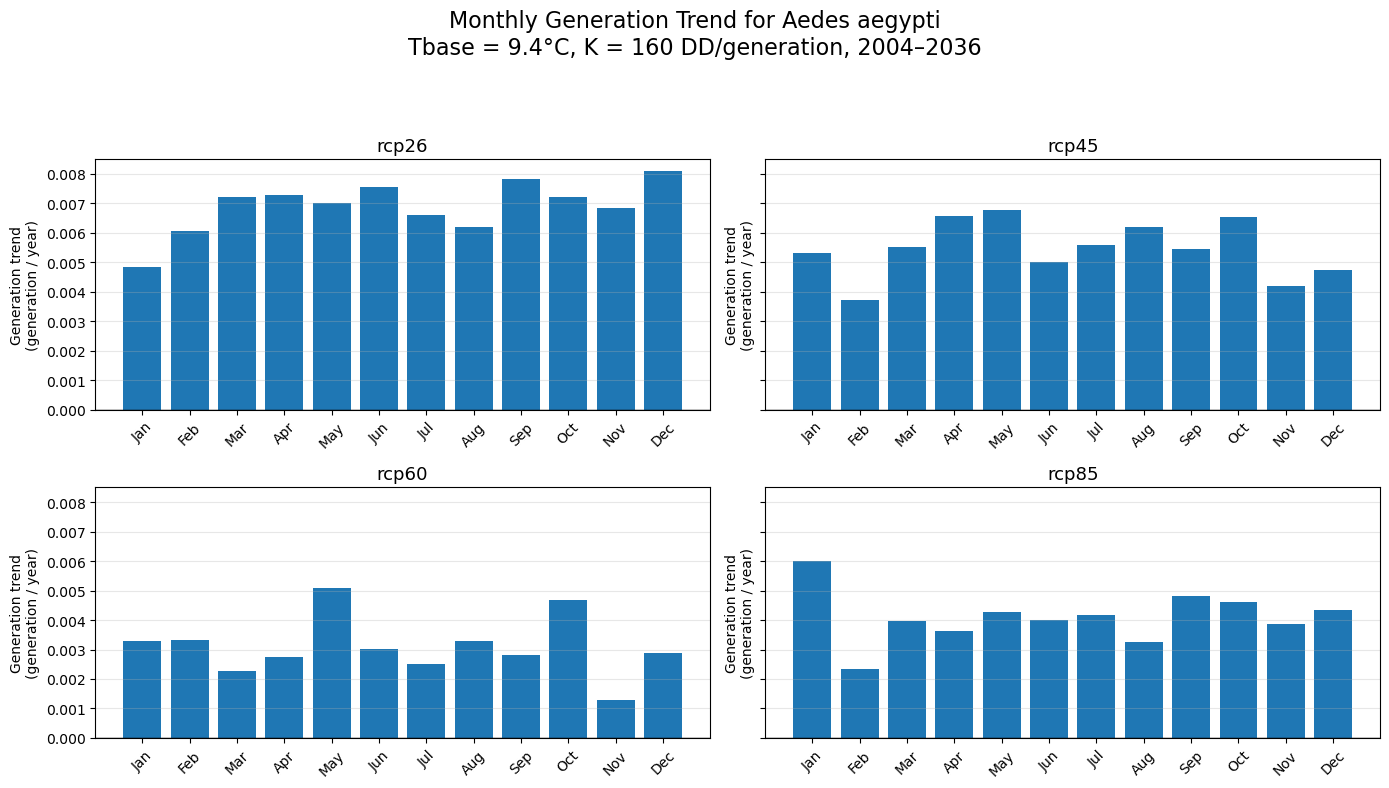

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_generation_slope_Aedes_aegypti_2004_2036.png


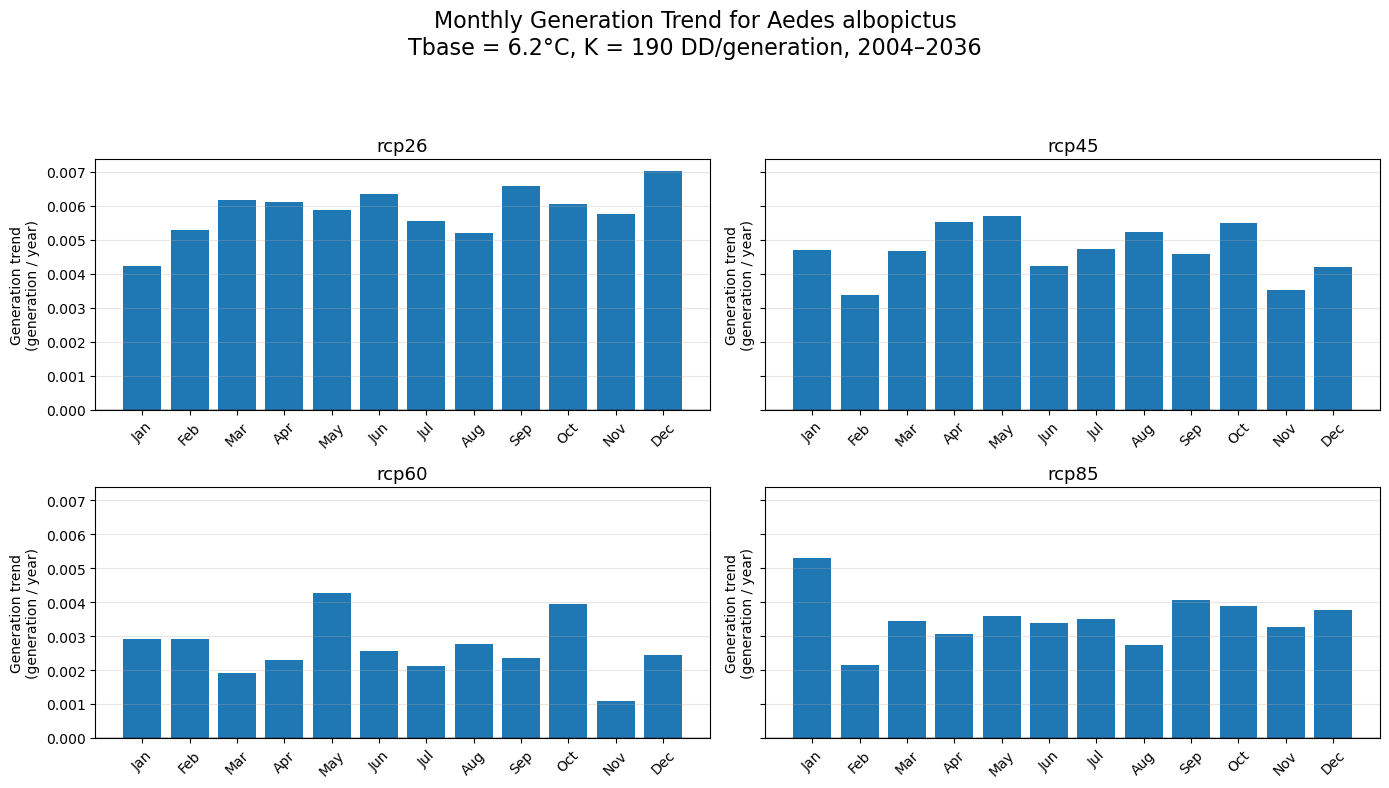

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_generation_slope_Aedes_albopictus_2004_2036.png


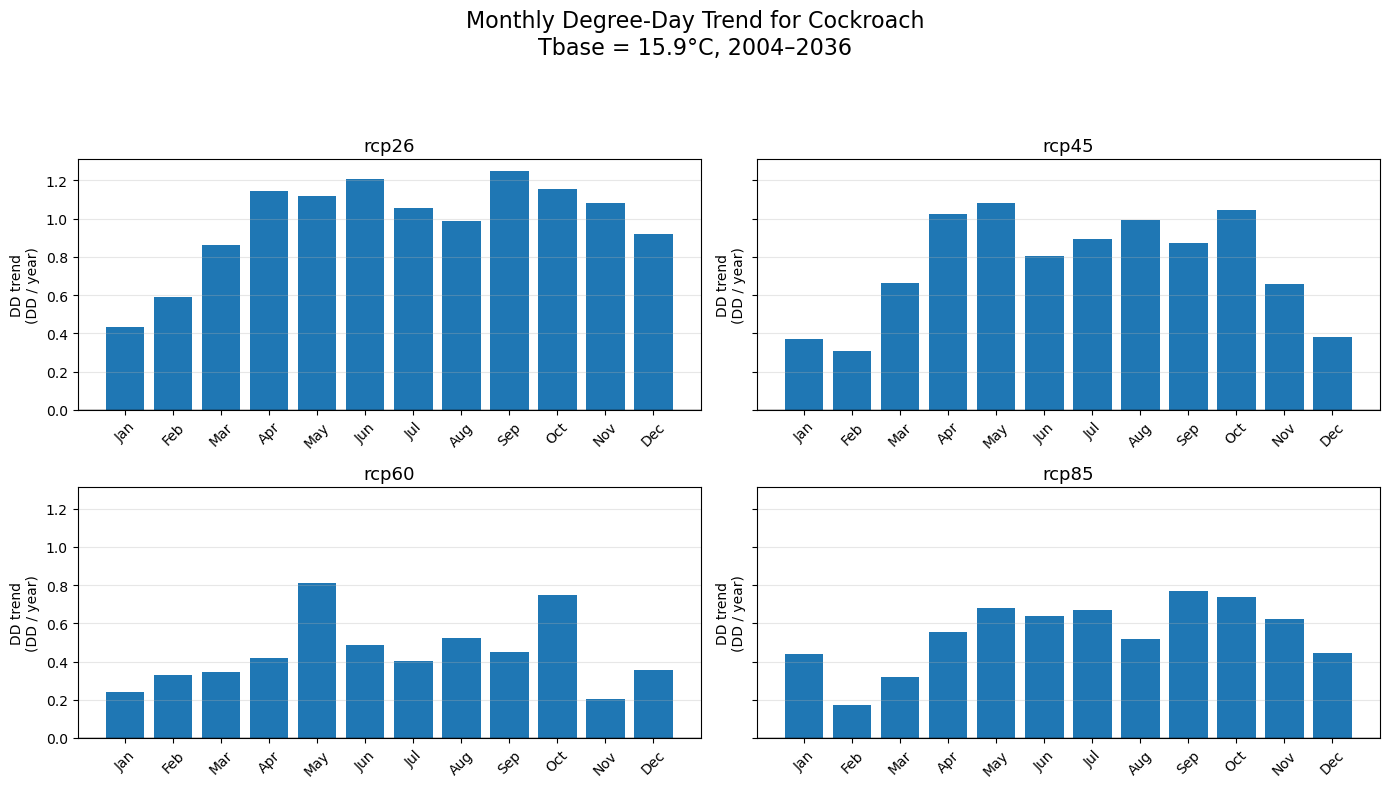

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_DD_slope_Cockroach_2004_2036.png


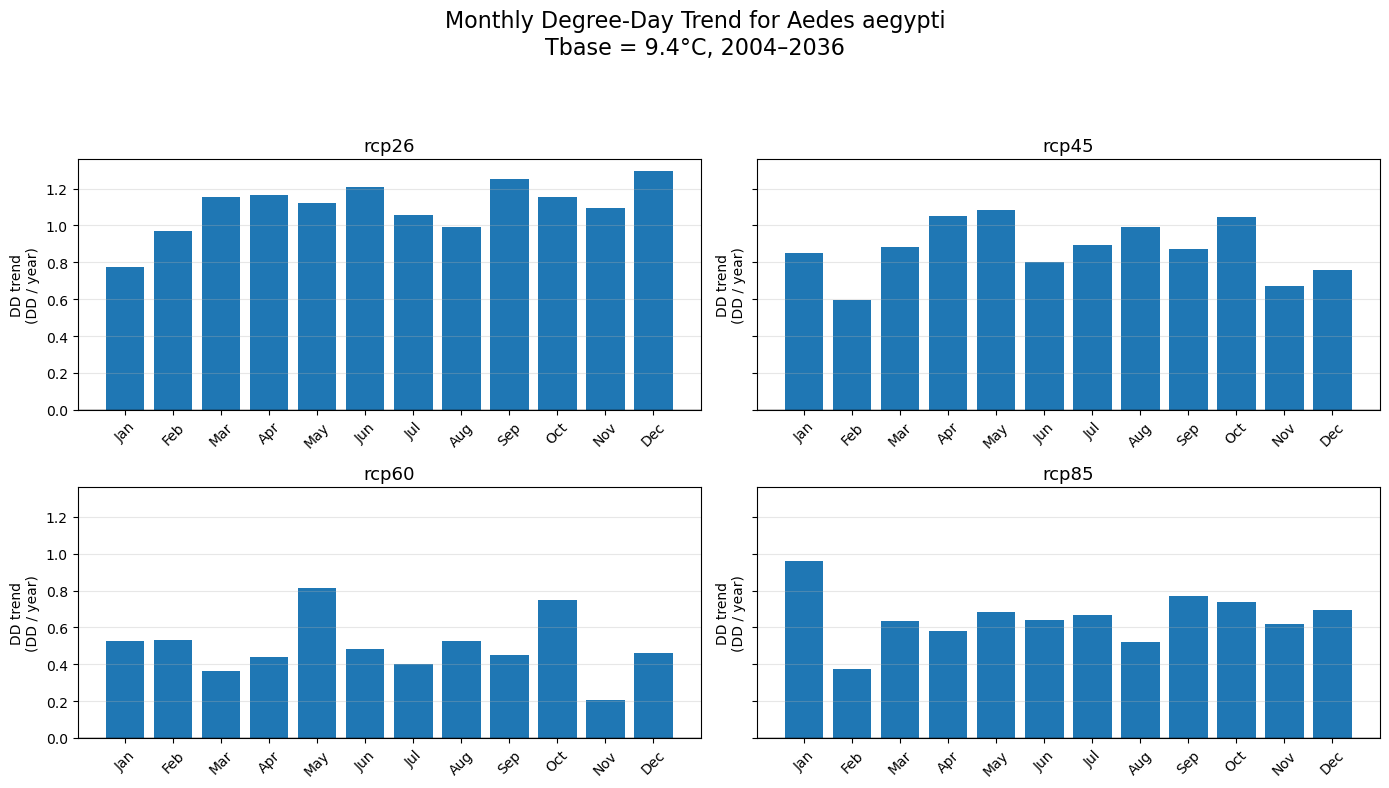

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_DD_slope_Aedes_aegypti_2004_2036.png


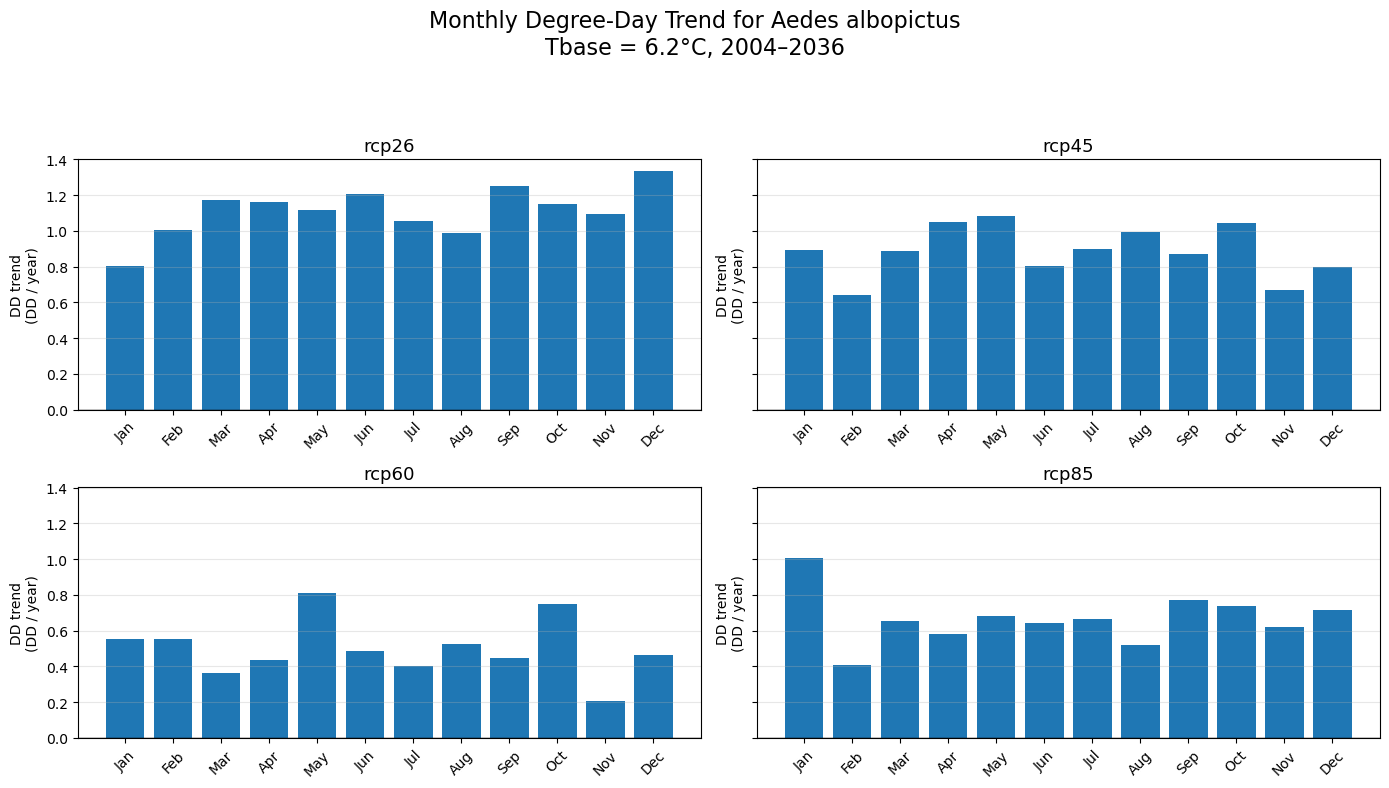

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope\Monthly_DD_slope_Aedes_albopictus_2004_2036.png


In [1]:
# ============================================================
# Monthly Degree-Day and Generation Trend Analysis
# Cockroach + Aedes aegypti + Aedes albopictus
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Basic settings
# ============================================================

FILE_PATH = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet"

OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_generation_slope")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = 2004
END_YEAR = 2036

SCENARIO_ORDER = ["rcp26", "rcp45", "rcp60", "rcp85"]

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# ============================================================
# 2. Organism settings
# ============================================================

ORGANISMS = {
    "Cockroach": {
        "base_temp": 15.9,
        "dd_per_generation": 650
    },
    "Aedes aegypti": {
        "base_temp": 9.4,
        "dd_per_generation": 160   # midpoint of 145–176 DD
    },
    "Aedes albopictus": {
        "base_temp": 6.2,
        "dd_per_generation": 190   # midpoint of 166–214 DD
    }
}

# ============================================================
# 3. Read data
# ============================================================

df = pd.read_parquet(FILE_PATH)

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["scenario"] = df["scenario"].astype(str).str.lower()
df["model"] = df["model"].astype(str)

# Use corrected value if available, otherwise use value
if "value_corrected" in df.columns:
    temp_col = "value_corrected"
else:
    temp_col = "value"

df[temp_col] = pd.to_numeric(df[temp_col], errors="coerce")

df = df[
    (df["year"] >= START_YEAR) &
    (df["year"] <= END_YEAR)
].copy()

df = df.dropna(subset=["date", temp_col, "model", "scenario"])
df = df.drop_duplicates(subset=["scenario", "model", "date"])

print("Cleaned data shape:", df.shape)
print("Temperature column used:", temp_col)
print(df.head())

# ============================================================
# 4. Calculate monthly DD and generation equivalent
# ============================================================

monthly_all = []

for organism, params in ORGANISMS.items():

    base_temp = params["base_temp"]
    dd_per_generation = params["dd_per_generation"]

    temp = df.copy()

    temp["organism"] = organism
    temp["base_temp"] = base_temp
    temp["dd_per_generation"] = dd_per_generation

    # Daily degree-day
    temp["dd_daily"] = (temp[temp_col] - base_temp).clip(lower=0)

    # Monthly DD
    monthly = (
        temp
        .groupby(
            ["organism", "scenario", "model", "year", "month",
             "base_temp", "dd_per_generation"],
            as_index=False
        )["dd_daily"]
        .sum()
        .rename(columns={"dd_daily": "monthly_dd"})
    )

    # Monthly generation equivalent
    monthly["monthly_generation_equivalent"] = (
        monthly["monthly_dd"] / monthly["dd_per_generation"]
    )

    monthly_all.append(monthly)

monthly_all = pd.concat(monthly_all, ignore_index=True)

print("Monthly data:")
print(monthly_all.head())

# ============================================================
# 5. Ensemble mean by organism / scenario / year / month
# ============================================================

ensemble_monthly = (
    monthly_all
    .groupby(["organism", "scenario", "year", "month"], as_index=False)
    .agg(
        ensemble_monthly_dd=("monthly_dd", "mean"),
        ensemble_monthly_generation=("monthly_generation_equivalent", "mean"),
        n_models=("model", "nunique")
    )
)

print("Ensemble monthly data:")
print(ensemble_monthly.head())

# ============================================================
# 6. Calculate monthly slope
# ============================================================

slope_records = []

for (organism, scenario, month), g in ensemble_monthly.groupby(
    ["organism", "scenario", "month"]
):

    g = g.sort_values("year").dropna(subset=["ensemble_monthly_generation"])

    if len(g) >= 2:
        slope_gen, intercept_gen = np.polyfit(
            g["year"],
            g["ensemble_monthly_generation"],
            1
        )

        slope_dd, intercept_dd = np.polyfit(
            g["year"],
            g["ensemble_monthly_dd"],
            1
        )
    else:
        slope_gen = np.nan
        slope_dd = np.nan

    slope_records.append({
        "organism": organism,
        "scenario": scenario,
        "month": month,
        "slope_generation_per_year": slope_gen,
        "slope_dd_per_year": slope_dd
    })

monthly_slope = pd.DataFrame(slope_records)

monthly_slope = monthly_slope.sort_values(
    ["organism", "scenario", "month"]
).reset_index(drop=True)

print("Monthly slope:")
print(monthly_slope.head(30))

# Save slope table
slope_csv_path = OUTPUT_DIR / f"monthly_generation_slope_{START_YEAR}_{END_YEAR}.csv"
monthly_slope.to_csv(slope_csv_path, index=False, encoding="utf-8-sig")

print("Saved slope table:", slope_csv_path)

# ============================================================
# 7. Plot: one figure per organism
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = monthly_slope[
        monthly_slope["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[
            plot_df["scenario"] == scenario
        ].copy()

        sub = (
            sub
            .set_index("month")
            .reindex(range(1, 13))
            .reset_index()
        )

        ax.bar(
            sub["month"],
            sub["slope_generation_per_year"]
        )

        ax.axhline(0, color="black", linewidth=1)

        ax.set_title(scenario, fontsize=13)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS, rotation=45)

        ax.set_ylabel("Generation trend\n(generation / year)")
        ax.grid(axis="y", alpha=0.3)

    base_temp = ORGANISMS[organism]["base_temp"]
    dd_per_gen = ORGANISMS[organism]["dd_per_generation"]

    fig.suptitle(
        f"Monthly Generation Trend for {organism}\n"
        f"Tbase = {base_temp}°C, K = {dd_per_gen} DD/generation, {START_YEAR}–{END_YEAR}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    safe_name = (
        organism
        .replace(" ", "_")
        .replace(".", "")
    )

    outpath = OUTPUT_DIR / f"Monthly_generation_slope_{safe_name}_{START_YEAR}_{END_YEAR}.png"

    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", outpath)

# ============================================================
# 8. Optional: Plot monthly DD slope instead of generation slope
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = monthly_slope[
        monthly_slope["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[
            plot_df["scenario"] == scenario
        ].copy()

        sub = (
            sub
            .set_index("month")
            .reindex(range(1, 13))
            .reset_index()
        )

        ax.bar(
            sub["month"],
            sub["slope_dd_per_year"]
        )

        ax.axhline(0, color="black", linewidth=1)

        ax.set_title(scenario, fontsize=13)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS, rotation=45)

        ax.set_ylabel("DD trend\n(DD / year)")
        ax.grid(axis="y", alpha=0.3)

    base_temp = ORGANISMS[organism]["base_temp"]

    fig.suptitle(
        f"Monthly Degree-Day Trend for {organism}\n"
        f"Tbase = {base_temp}°C, {START_YEAR}–{END_YEAR}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    safe_name = (
        organism
        .replace(" ", "_")
        .replace(".", "")
    )

    outpath = OUTPUT_DIR / f"Monthly_DD_slope_{safe_name}_{START_YEAR}_{END_YEAR}.png"

    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", outpath)

Data period: 2004-05-01 00:00:00 to 2036-04-30 00:00:00
Biological years: 2004 to 2035


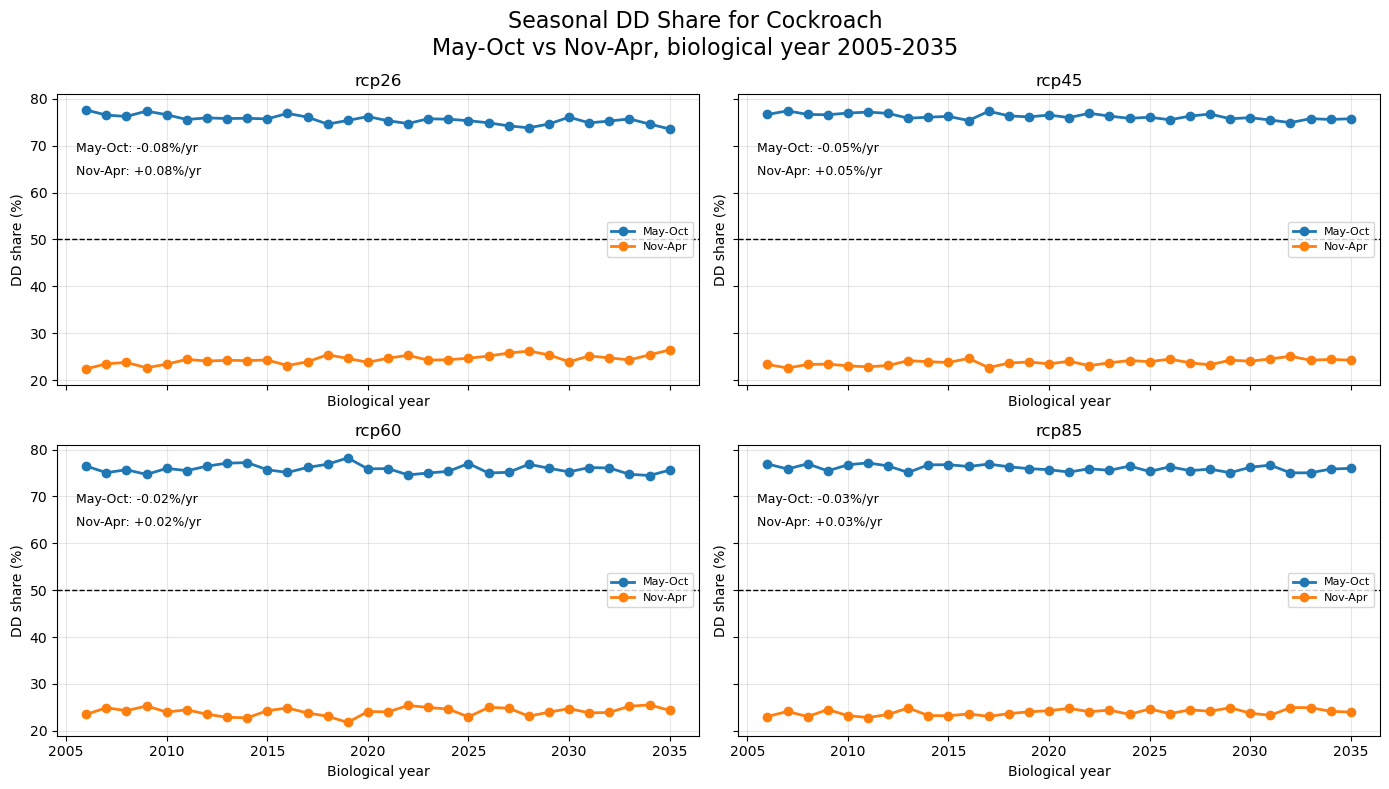

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_Cockroach_2005_2035.png


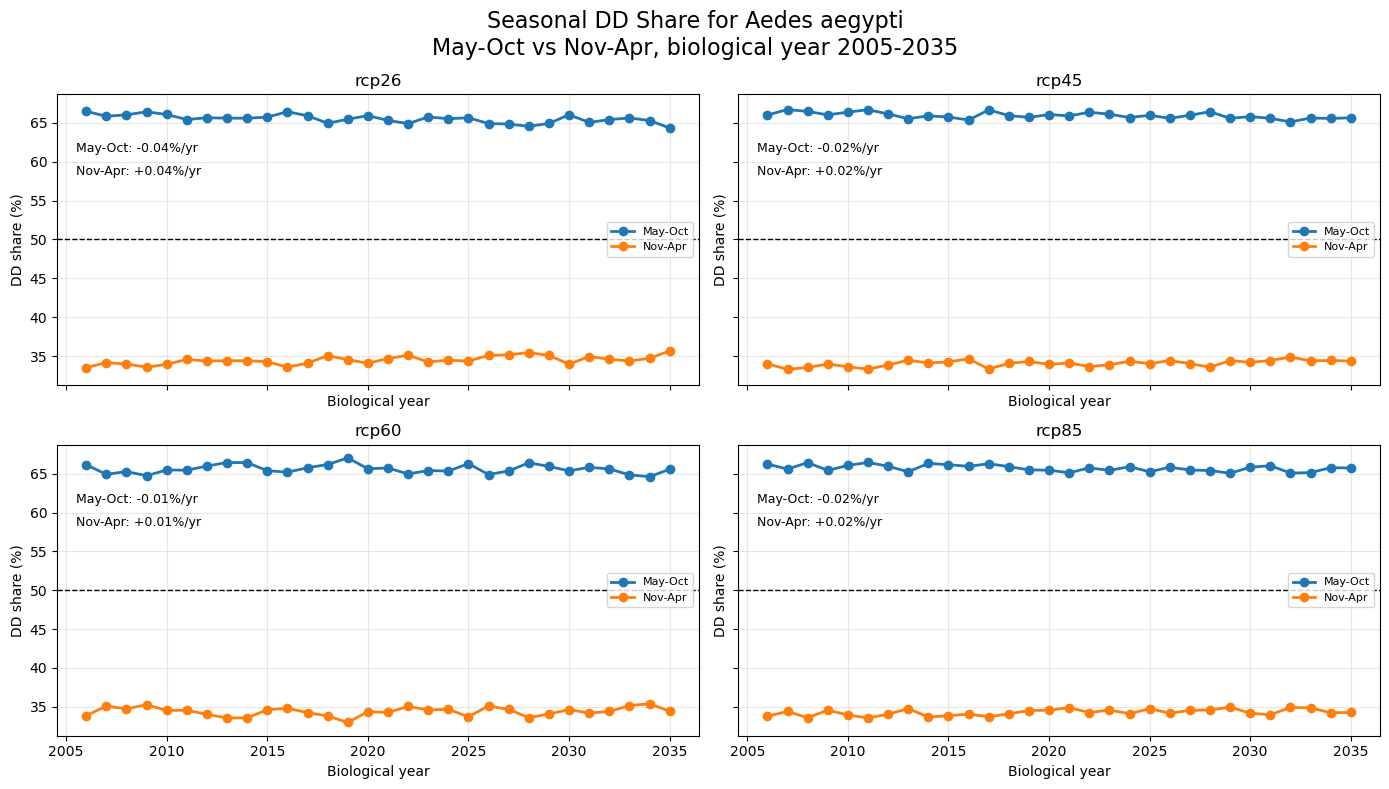

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_Aedes_aegypti_2005_2035.png


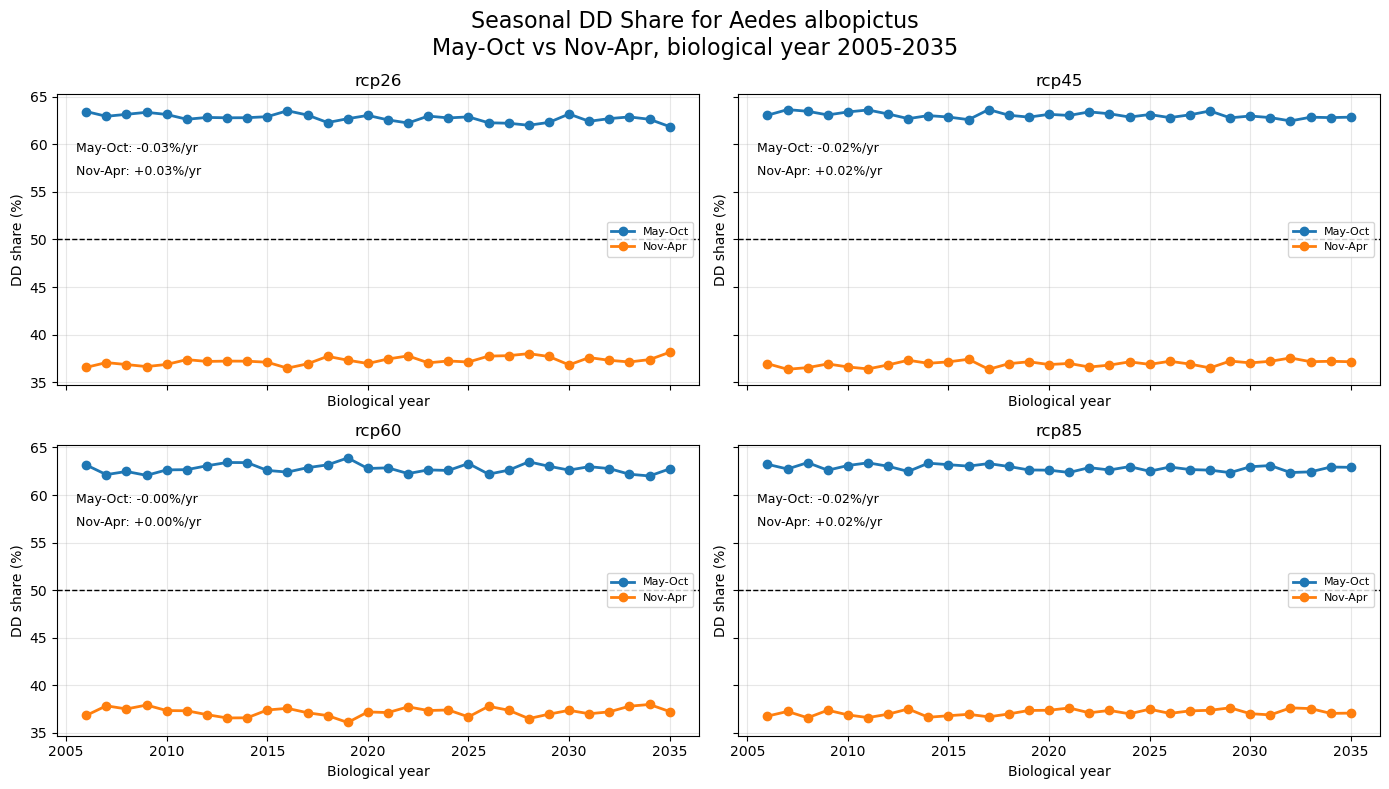

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_Aedes_albopictus_2005_2035.png


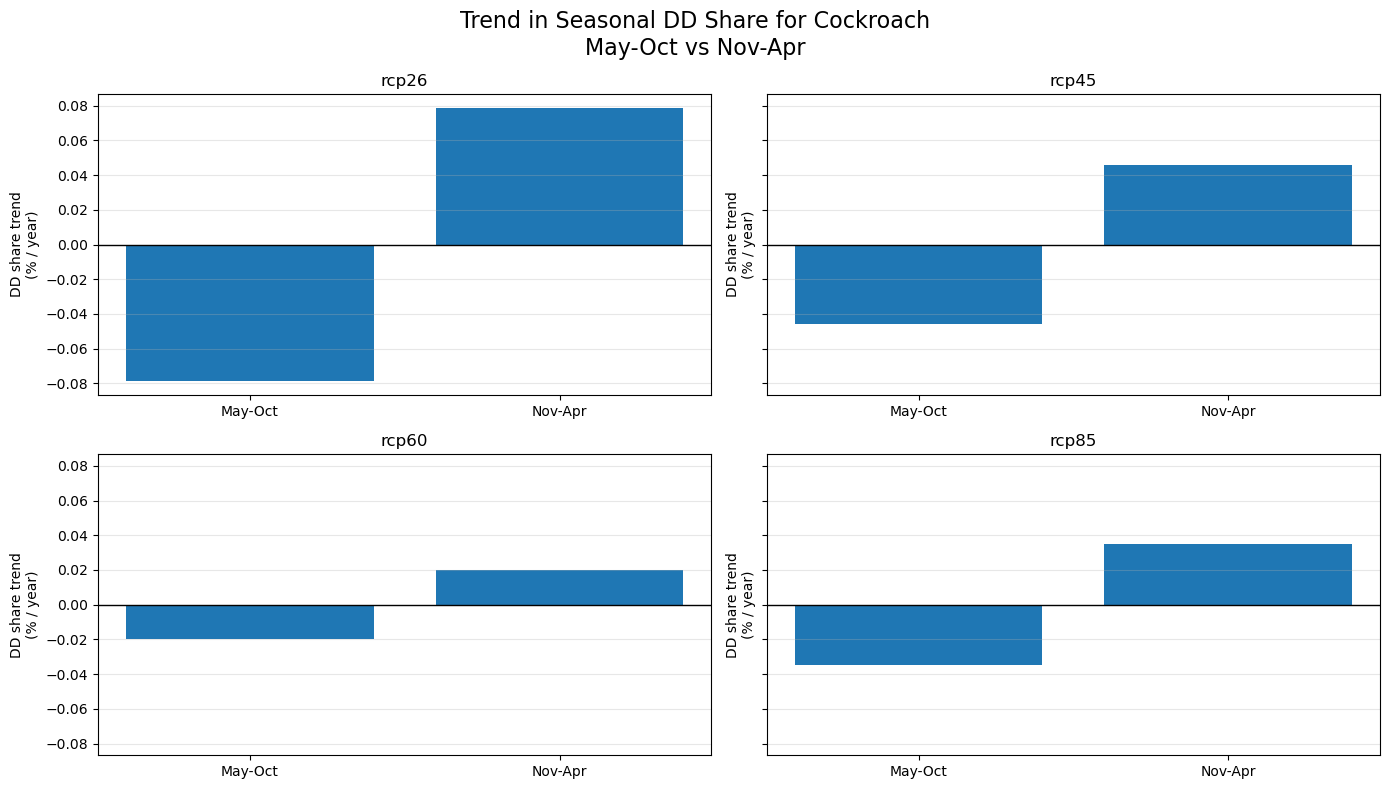

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_slope_Cockroach_2005_2035.png


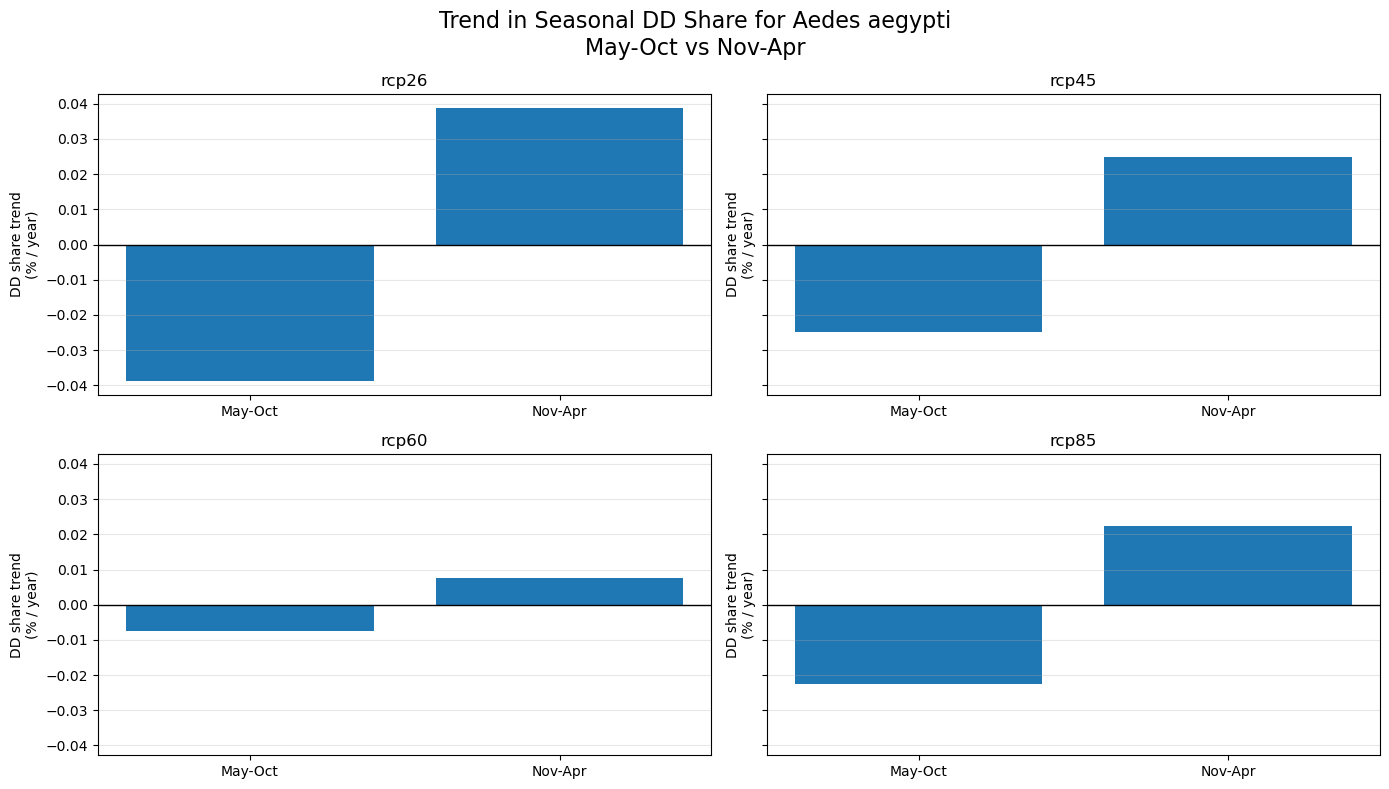

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_slope_Aedes_aegypti_2005_2035.png


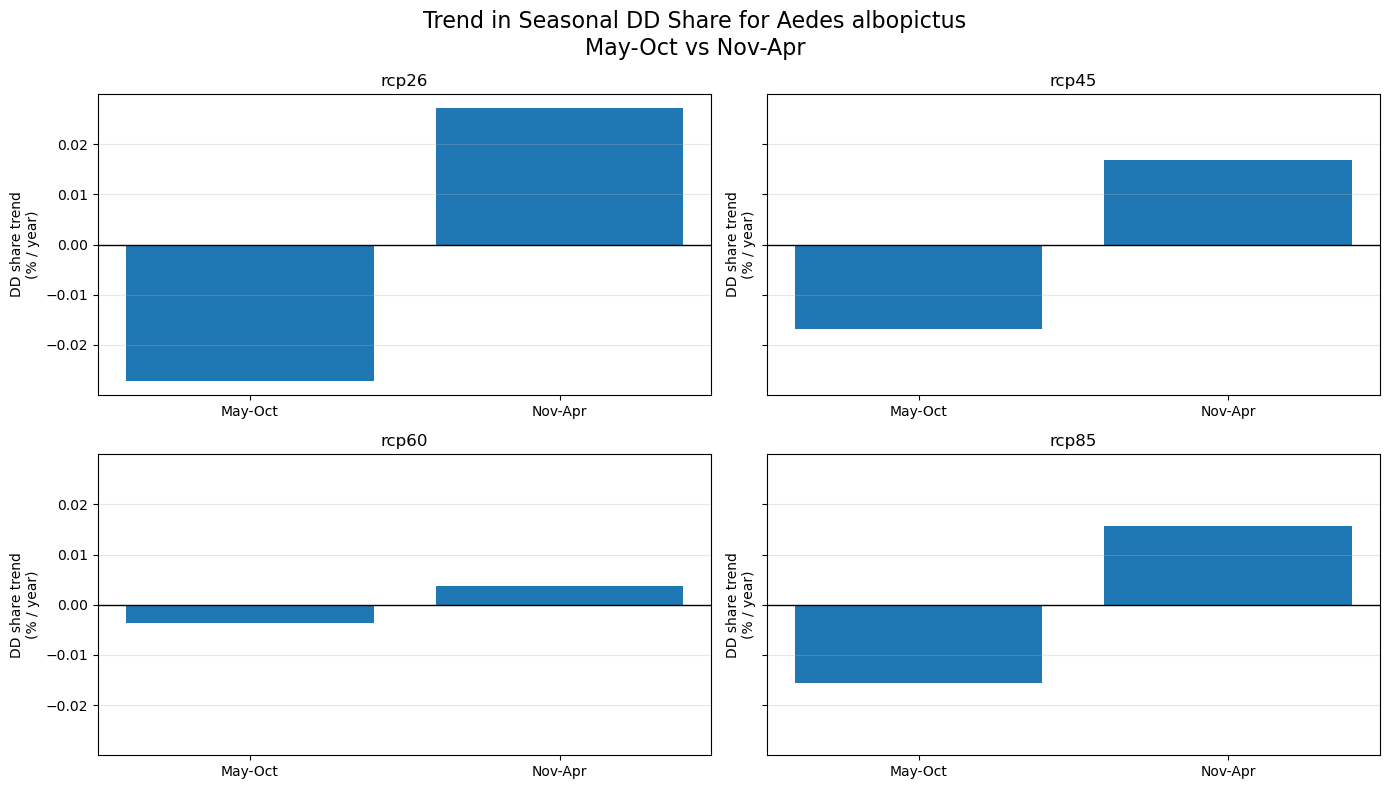

Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share\Seasonal_DD_share_slope_Aedes_albopictus_2005_2035.png


In [23]:
# ============================================================
# Seasonal DD Share Analysis
# Warm season: May–Oct
# Cool season: Nov–Apr
# Period: 2004-05 to 2037-04
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILE_PATH = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet"

OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\seasonal_dd_share")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_ORDER = ["rcp26", "rcp45", "rcp60", "rcp85"]

ORGANISMS = {
    "Cockroach": {
        "base_temp": 15.9,
        "dd_per_generation": 650
    },
    "Aedes aegypti": {
        "base_temp": 9.4,
        "dd_per_generation": 160
    },
    "Aedes albopictus": {
        "base_temp": 6.2,
        "dd_per_generation": 190
    }
}

# ============================================================
# 1. Read data
# ============================================================

df = pd.read_parquet(FILE_PATH)

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["scenario"] = df["scenario"].astype(str).str.lower()
df["model"] = df["model"].astype(str)

if "value_corrected" in df.columns:
    temp_col = "value_corrected"
else:
    temp_col = "value"

df[temp_col] = pd.to_numeric(df[temp_col], errors="coerce")

# 2004-05-01 to 2037-04-30
df = df[
    (df["date"] >= "2004-05-01") &
    (df["date"] <= "2036-04-30")
].copy()

df = df.dropna(subset=["date", temp_col, "model", "scenario"])
df = df.drop_duplicates(subset=["scenario", "model", "date"])

# ============================================================
# 2. Define biological year and season group
# ============================================================

# biological year starts in May
# May-Oct belongs to current year
# Nov-Dec belongs to current year
# Jan-Apr belongs to previous biological year

df["bio_year"] = np.where(
    df["month"].isin([1, 2, 3, 4]),
    df["year"] - 1,
    df["year"]
)

df["season_group"] = np.where(
    df["month"].isin([5, 6, 7, 8, 9, 10]),
    "May-Oct",
    "Nov-Apr"
)

df = df[
    (df["bio_year"] >= 2004) &
    (df["bio_year"] <= 2035)
].copy()

print("Data period:", df["date"].min(), "to", df["date"].max())
print("Biological years:", df["bio_year"].min(), "to", df["bio_year"].max())

# 檢查每個 bio_year 是否有完整 12 個月
month_check = (
    df.groupby(["scenario", "model", "bio_year"])["month"]
    .nunique()
    .reset_index(name="n_months")
)

valid = month_check[month_check["n_months"] == 12]

df = df.merge(
    valid[["scenario", "model", "bio_year"]],
    on=["scenario", "model", "bio_year"],
    how="inner"
)

# ============================================================
# 3. Calculate DD by organism
# ============================================================

seasonal_all = []

for organism, params in ORGANISMS.items():

    base_temp = params["base_temp"]
    dd_per_generation = params["dd_per_generation"]

    temp = df.copy()
    temp["organism"] = organism
    temp["base_temp"] = base_temp
    temp["dd_per_generation"] = dd_per_generation

    temp["dd_daily"] = (temp[temp_col] - base_temp).clip(lower=0)

    seasonal = (
        temp
        .groupby(
            ["organism", "scenario", "model", "bio_year", "season_group",
             "base_temp", "dd_per_generation"],
            as_index=False
        )["dd_daily"]
        .sum()
        .rename(columns={"dd_daily": "seasonal_dd"})
    )

    seasonal["seasonal_generation_equivalent"] = (
        seasonal["seasonal_dd"] / seasonal["dd_per_generation"]
    )

    seasonal_all.append(seasonal)

seasonal_all = pd.concat(seasonal_all, ignore_index=True)

# ============================================================
# 4. Calculate seasonal DD share
# ============================================================

total_dd = (
    seasonal_all
    .groupby(["organism", "scenario", "model", "bio_year"], as_index=False)["seasonal_dd"]
    .sum()
    .rename(columns={"seasonal_dd": "annual_bioyear_dd"})
)

seasonal_share = seasonal_share[
    seasonal_share["bio_year"] != 2004
]

seasonal_share = seasonal_all.merge(
    total_dd,
    on=["organism", "scenario", "model", "bio_year"],
    how="left"
)

seasonal_share["dd_share"] = (
    #seasonal_share["bio_year"] != 2004
    seasonal_share["seasonal_dd"] / seasonal_share["annual_bioyear_dd"] * 100
)

# ============================================================
# 5. Ensemble mean share
# ============================================================

ensemble_share = (
    seasonal_share
    .groupby(["organism", "scenario", "bio_year", "season_group"], as_index=False)
    .agg(
        ensemble_dd_share=("dd_share", "mean"),
        ensemble_seasonal_dd=("seasonal_dd", "mean"),
        n_models=("model", "nunique")
    )
)

# ============================================================
# 6. Calculate slope of seasonal share
# ============================================================

slope_records = []

for (organism, scenario, season_group), g in ensemble_share.groupby(
    ["organism", "scenario", "season_group"]
):

    g = g.sort_values("bio_year")

    if len(g) >= 2:
        slope_share, intercept_share = np.polyfit(
            g["bio_year"],
            g["ensemble_dd_share"],
            1
        )
    else:
        slope_share = np.nan

    slope_records.append({
        "organism": organism,
        "scenario": scenario,
        "season_group": season_group,
        "slope_share_percent_per_year": slope_share
    })

seasonal_share_slope = pd.DataFrame(slope_records)

# save
seasonal_share.to_csv(
    OUTPUT_DIR / "seasonal_dd_share_by_model.csv",
    index=False,
    encoding="utf-8-sig"
)

ensemble_share.to_csv(
    OUTPUT_DIR / "seasonal_dd_share_ensemble.csv",
    index=False,
    encoding="utf-8-sig"
)

seasonal_share_slope.to_csv(
    OUTPUT_DIR / "seasonal_dd_share_slope.csv",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 7. Plot time series: DD share over biological year
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = ensemble_share[
        ensemble_share["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[plot_df["scenario"] == scenario].copy()

        for season_group in ["May-Oct", "Nov-Apr"]:

            s = sub[sub["season_group"] == season_group].sort_values("bio_year")

            ax.plot(
                s["bio_year"],
                s["ensemble_dd_share"],
                marker="o",
                linewidth=2,
                label=season_group
            )

            if len(s) >= 2:
                slope, intercept = np.polyfit(
                    s["bio_year"],
                    s["ensemble_dd_share"],
                    1
                )

                ax.text(
                    0.03,
                    0.80 if season_group == "May-Oct" else 0.72,
                    f"{season_group}: {slope:+.2f}%/yr",
                    transform=ax.transAxes,
                    fontsize=9
                )

        ax.axhline(50, color="black", linewidth=1, linestyle="--")
        ax.set_title(scenario)
        ax.set_xlabel("Biological year")
        ax.set_ylabel("DD share (%)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    fig.suptitle(
        f"Seasonal DD Share for {organism}\n"
        f"May-Oct vs Nov-Apr, biological year 2005-2035",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 1])

    safe_name = organism.replace(" ", "_").replace(".", "")

    outpath = OUTPUT_DIR / f"Seasonal_DD_share_{safe_name}_2005_2035.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)

# ============================================================
# 8. Plot bar chart: slope comparison
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = seasonal_share_slope[
        seasonal_share_slope["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[plot_df["scenario"] == scenario].copy()
        sub = sub.set_index("season_group").reindex(["May-Oct", "Nov-Apr"]).reset_index()

        ax.bar(
            sub["season_group"],
            sub["slope_share_percent_per_year"]
        )

        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(scenario)
        ax.set_ylabel("DD share trend\n(% / year)")
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(
        f"Trend in Seasonal DD Share for {organism}\n"
        f"May-Oct vs Nov-Apr",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 1])

    safe_name = organism.replace(" ", "_").replace(".", "")

    outpath = OUTPUT_DIR / f"Seasonal_DD_share_slope_{safe_name}_2005_2035.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", outpath)

In [4]:
check = (
    df[df["bio_year"] == 2004]
    .groupby("season_group")["month"]
    .unique()
)

print(check)

season_group
May-Oct     [5, 6, 7, 8, 9, 10]
Nov-Apr    [11, 12, 1, 2, 3, 4]
Name: month, dtype: object
